<div style="background-color: #2c3e50; color: white; padding: 20px; border-radius: 10px; font-family: sans-serif;">
    <h1 style="color: white; border-bottom: 2px solid #ecf0f1; padding-bottom: 10px;">EEG Tabanlı Epilepsi Tespiti - TCN MODELİ</h1>
    <h3 style="color: #bdc3c7;">Bonn Üniversitesi EEG Veri Seti Analizi</h3>
    <p style="font-size: 0.9em; margin-top: 15px;">
        <strong>Ders:</strong> Makine Öğrenmesi | 
        <strong>Konu:</strong> Zaman Serisi Sınıflandırma | 
        <strong>Model:</strong> TCN
    </p>
</div>

<div style="background-color: #ecf0f1; color: #2c3e50; padding: 15px; border-left: 6px solid #2c3e50; margin-top: 10px; font-family: sans-serif;">
    <h3 style="margin-top: 0;">📋 Proje Özeti ve Teknik Strateji</h3>
    <p>Bu çalışma, Bonn Üniversitesi veri setini kullanarak <strong>Sağlıklı</strong> ve <strong>Nöbet</strong> durumlarını ayırt etmeyi hedefler. Model olarak <em>Temporal Convolutional Network (TCN)</em> kullanılmıştır.</p>
    <ul>
        <li><strong>Veri Sızıntısı Önlemi:</strong> Veri önce %80-20 ayrılmış, <em>ardından</em> parçalanmıştır.</li>
        <li><strong>Veri Çoğaltma (Augmentation):</strong> Eğitim setinde örtüşmeli pencereler (Stride: 512) kullanılmıştır.</li>
        <li><strong>Kritik Karar:</strong> Nöbet yakalama hassasiyetini artırmak için test aşamasında eşik değeri (threshold) <strong>0.3</strong> olarak belirlenmiştir.</li>
    </ul>
</div>

<div style="background-color: #e8f4f8; border-left: 5px solid #3498db; padding: 10px; font-family: sans-serif;">
    <h3 style="color: #2980b9; margin-top: 0;">1. Kütüphaneler ve Ortam Hazırlığı</h3>
    <p>Gerekli kütüphaneler yüklenir. Sonuçların her çalıştırıldığında aynı olması için rastgelelik tohumu (<code>SEED = 123</code>) sabitlenir.</p>
</div>

In [1]:
# ============================================================================
# HÜCRE 1: KÜTÜPHANE YÜKLEME VE AYARLAR
# ============================================================================

import numpy as np
import tensorflow as tf
import random
import warnings
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, confusion_matrix, roc_curve, auc, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, Callback

warnings.filterwarnings('ignore')

# SEED sabitleme
SEED = 123
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(" Kütüphaneler yüklendi")
print(f"TensorFlow: {tf.__version__}")
print(f"SEED: {SEED}")

C:\Users\emiri\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


 Kütüphaneler yüklendi
TensorFlow: 2.20.0
SEED: 123


<div style="background-color: #e8f4f8; border-left: 5px solid #3498db; padding: 10px; font-family: sans-serif;">
    <h3 style="color: #2980b9; margin-top: 0;">2. Veri Setinin Yüklenmesi</h3>
    <p>Belirtilen klasörlerden sinyaller okunur:</p>
    <ul>
        <li><strong>Set A (Z):</strong> Sağlıklı (0)</li>
        <li><strong>Set E (S):</strong> Epilepsi Nöbeti (1)</li>
    </ul>
</div>

In [2]:
# ============================================================================
# HÜCRE 2: VERİ YÜKLEME
# ============================================================================

# YOLLARINIZI BURAYA YAZIN
path_healthy = "C:/Users/emiri/Downloads/Z/"
path_seizure = "C:/Users/emiri/Downloads/S/"

def load_eeg_data(folder_path, label):
    data = []
    files = sorted([f for f in os.listdir(folder_path) if f.endswith('.txt')])
    print(f"  {len(files)} dosya bulundu")
    
    for file in files:
        signal = np.loadtxt(os.path.join(folder_path, file))
        data.append(signal)
    
    return np.array(data), np.full(len(data), label)

print("\n Veri yükleniyor...")
X_healthy, y_healthy = load_eeg_data(path_healthy, 0)
X_seizure, y_seizure = load_eeg_data(path_seizure, 1)

X = np.concatenate([X_healthy, X_seizure], axis=0)
y = np.concatenate([y_healthy, y_seizure], axis=0)

print(f"\n Veri yüklendi: {X.shape}")
print(f"   Sağlıklı: {len(y_healthy)} | Nöbet: {len(y_seizure)}")


 Veri yükleniyor...
  100 dosya bulundu
  100 dosya bulundu

 Veri yüklendi: (200, 4097)
   Sağlıklı: 100 | Nöbet: 100


<div style="background-color: #fff8e1; border-left: 5px solid #f1c40f; padding: 10px; font-family: sans-serif;">
    <h3 style="color: #d35400; margin-top: 0;">3. Kritik Adım: Bölümleme ve Segmentasyon</h3>
    <p>Veri sızıntısını (Data Leakage) önlemek için önce <code>train_test_split</code> yapılır, sonra parçalanır:</p>
    <ul>
        <li><strong>Eğitim:</strong> Window: 1024, Stride: 512 (Veri artırımı için örtüşmeli)</li>
        <li><strong>Test:</strong> Window: 1024, Stride: 1024 (Adil test için örtüşmesiz)</li>
    </ul>
</div>

In [3]:
# ============================================================================
# HÜCRE 3: VERİ ÖN İŞLEME (VERİ ÇOĞALTMA)
# ============================================================================

def segment_data(X, y, window_size=512, stride=256):
    """
    Uzun EEG sinyallerini daha küçük, örtüşen (overlapping) pencerelere böler.
    Böylece 200 olan veri sayısı binlere çıkar.
    """
    X_segmented = []
    y_segmented = []
    
    n_samples, n_time_steps = X.shape
    
    # Sinyal boyunca pencere kaydırma
    for i in range(n_samples):
        signal = X[i]
        label = y[i]
        
        for start in range(0, n_time_steps - window_size + 1, stride):
            end = start + window_size
            segment = signal[start:end]
            X_segmented.append(segment)
            y_segmented.append(label)
            
    return np.array(X_segmented), np.array(y_segmented)

# 1. Önce Veriyi Train-Test Olarak Böl (Sızıntıyı önlemek için önce bölünmeli)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"\n📊 Ham Veri Bölünmesi:")
print(f"   Train (Ham): {X_train_raw.shape}")
print(f"   Test (Ham):  {X_test_raw.shape}")

# 2. Veriyi Parçalara Böl (Augmentation)
# Pencere boyutu 1024 (yaklaşık 5-6 saniye), Kaydırma 512 (yarı yarıya örtüşmeli)
WINDOW_SIZE = 1024
STRIDE = 512

print("\n Veri parçalanıyor ve çoğaltılıyor...")
X_train_seg, y_train = segment_data(X_train_raw, y_train_raw, WINDOW_SIZE, STRIDE)
# Test verisini sadece örtüşmeden bölelim (stride=WINDOW_SIZE) ki test adil olsun
X_test_seg, y_test = segment_data(X_test_raw, y_test_raw, WINDOW_SIZE, WINDOW_SIZE)

# 3. Normalizasyon
scaler = StandardScaler()
# 2D hale getirip fit edelim, sonra tekrar 3D yapacağız
X_train_flat = X_train_seg.reshape(X_train_seg.shape[0], -1)
X_test_flat = X_test_seg.reshape(X_test_seg.shape[0], -1)

X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

# 4. Reshape (CNN/TCN için 3D format: Örnek, Zaman, Kanal)
X_train = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print(f"\n Veri Hazır:")
print(f"   Yeni Train Boyutu: {X_train.shape} (Artırılmış)")
print(f"   Yeni Test Boyutu:  {X_test.shape}")


📊 Ham Veri Bölünmesi:
   Train (Ham): (160, 4097)
   Test (Ham):  (40, 4097)

 Veri parçalanıyor ve çoğaltılıyor...

 Veri Hazır:
   Yeni Train Boyutu: (1120, 1024, 1) (Artırılmış)
   Yeni Test Boyutu:  (160, 1024, 1)


<div style="background-color: #e8f4f8; border-left: 5px solid #3498db; padding: 10px; font-family: sans-serif;">
    <h3 style="color: #2980b9; margin-top: 0;">4. TCN Model Mimarisi</h3>
    <p>Zaman serisi analizi için Genişleyen Konvolüsyonlar (Dilated Convolutions) kullanılır.</p>
    <ul>
        <li><strong>Genişleme Oranları:</strong> 1, 2, 4</li>
        <li><strong>Yapı:</strong> Conv1D + Causal Padding + BatchNormalization + Dropout</li>
    </ul>
</div>

In [4]:
# ============================================================================
# HÜCRE 4: TCN MODELİ
# ============================================================================

print(f"\n{'='*60}")
print(" TCN MODELİ OLUŞTURULUYOR")
print(f"{'='*60}")

model = models.Sequential([
    # 1. Giriş Katmanı [cite: 29]
    layers.Input(shape=(X_train.shape[1], 1)),
    
    # ---------------------------------------------------------
    # 2. Genişleyen Katmanlar (Dilated Conv1D) [cite: 30]
    # ---------------------------------------------------------
    
    # TCN Block 1 - dilation_rate=1 [cite: 33]
    layers.Conv1D(16, 5, dilation_rate=1, padding='causal', activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.MaxPooling1D(2), # Boyutu kontrol altında tutmak için
    
    # TCN Block 2 - dilation_rate=2 [cite: 35]
    layers.Conv1D(32, 5, dilation_rate=2, padding='causal', activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.MaxPooling1D(2),
    
    # TCN Block 3 - dilation_rate=4 [cite: 36]
    layers.Conv1D(64, 5, dilation_rate=4, padding='causal', activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    
    # ---------------------------------------------------------
    # 3. Düzleştirme (Flatten) 
    # ---------------------------------------------------------
    # GlobalAveragePooling1D yerine Flatten kullanıyoruz.
    layers.Flatten(),
    
    # ---------------------------------------------------------
    # 4. Sonuç Katmanı (Dense + Sigmoid) 
    # ---------------------------------------------------------
    # Ara Dense Katman (Öğrenme kapasitesi için)
    layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)),
    layers.Dropout(0.5), # Ezberlemeyi önlemek için son önlem
    
    # Çıkış (0 veya 1 sınıflandırma)
    layers.Dense(1, activation='sigmoid')
])

# Compile (Derleme)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(" Model oluşturuldu")
model.summary()


 TCN MODELİ OLUŞTURULUYOR
 Model oluşturuldu


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 1024, 16)       │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024, 16)       │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 512, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 512, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 256, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 256, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       524,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 537,793 (2.05 MB)

 Trainable params: 537,569 (2.05 MB)

 Non-trainable params: 224 (896.00 B)

<div style="background-color: #e8f4f8; border-left: 5px solid #3498db; padding: 10px; font-family: sans-serif;">
    <h3 style="color: #2980b9; margin-top: 0;">5. Callback Fonksiyonları</h3>
    <p>Eğitim sürecini optimize etmek için F1-Score takibi, Erken Durdurma (Early Stopping) ve Learning Rate azaltma araçları tanımlanır.</p>
</div>

In [5]:
# ============================================================================
# HÜCRE 5: CALLBACK TANIMLARI
# ============================================================================

class F1ScoreCallback(Callback):
    def __init__(self, train_data, val_data):
        super().__init__()
        self.train_data = train_data
        self.val_data = val_data
        self.f1_train = []
        self.f1_val = []
    
    def on_epoch_end(self, epoch, logs=None):
        X_tr, y_tr = self.train_data
        y_pred_tr = (self.model.predict(X_tr, verbose=0) > 0.5).astype(int).flatten()
        f1_tr = f1_score(y_tr, y_pred_tr)
        self.f1_train.append(f1_tr)
        
        X_v, y_v = self.val_data
        y_pred_v = (self.model.predict(X_v, verbose=0) > 0.5).astype(int).flatten()
        f1_v = f1_score(y_v, y_pred_v)
        self.f1_val.append(f1_v)
        
        logs['f1'] = f1_tr
        logs['val_f1'] = f1_v
        print(f" - f1: {f1_tr:.4f} - val_f1: {f1_v:.4f}")

# Train-Validation split (Artırılmış veri üzerinden)
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=SEED, stratify=y_train
)

print(f"\n Veri dağılımı:")
print(f"   Train: {X_train_final.shape[0]}")
print(f"   Val: {X_val.shape[0]}")
print(f"   Test: {X_test.shape[0]}")

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

f1_callback = F1ScoreCallback(
    train_data=(X_train_final, y_train_final),
    val_data=(X_val, y_val)
)


 Veri dağılımı:
   Train: 896
   Val: 224
   Test: 160


<div style="background-color: #e8f4f8; border-left: 5px solid #3498db; padding: 10px; font-family: sans-serif;">
    <h3 style="color: #2980b9; margin-top: 0;">6. Modelin Eğitilmesi</h3>
    <p>Model, belirlenen parametrelerle eğitilir ve doğrulama seti (Validation Set) üzerinde performansı anlık olarak izlenir.</p>
</div>

In [6]:
# ============================================================================
# HÜCRE 6: MODEL EĞİTİMİ
# ============================================================================

print(f"\n{'='*60}")
print(" EĞİTİM BAŞLIYOR")
print(f"{'='*60}\n")

history = model.fit(
    X_train_final, y_train_final,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[f1_callback, early_stop, reduce_lr],
    verbose=1
)

print(f"\n{'='*60}")
print(" EĞİTİM TAMAMLANDI")
print(f"   Toplam epoch: {len(history.history['loss'])}")
print(f"   Best val_acc: {max(history.history['val_accuracy']):.4f}")
print(f"{'='*60}")


 EĞİTİM BAŞLIYOR

Epoch 1/50
 - f1: 0.6667 - val_f1: 0.6667━━━━━━━━━ 0s 17ms/step - accuracy: 0.8270 - loss: 1.0378
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.9185 - loss: 0.8138 - val_accuracy: 0.5000 - val_loss: 1.1689 - f1: 0.6667 - val_f1: 0.6667 - learning_rate: 5.0000e-04
Epoch 2/50
 - f1: 0.9989 - val_f1: 1.0000━━━━━━━━━ 0s 17ms/step - accuracy: 0.9673 - loss: 0.6448
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9721 - loss: 0.6467 - val_accuracy: 1.0000 - val_loss: 0.7181 - f1: 0.9989 - val_f1: 1.0000 - learning_rate: 5.0000e-04
Epoch 3/50
 - f1: 0.9359 - val_f1: 0.9384━━━━━━━━━ 0s 17ms/step - accuracy: 0.9735 - loss: 0.5458
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9810 - loss: 0.5229 - val_accuracy: 0.9420 - val_loss: 0.5702 - f1: 0.9359 - val_f1: 0.9384 - learning_rate: 5.0000e-04
Epoch 4/50
 - f1: 0.9046 - val_f1: 0.9073━━━━━━━━━ 0s 17ms/step - accuracy: 0.9923 - loss: 0.4669
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9888 - loss: 

<div style="background-color: #eafaf1; border-left: 5px solid #2ecc71; padding: 10px; font-family: sans-serif;">
    <h3 style="color: #27ae60; margin-top: 0;">7. Test ve Değerlendirme</h3>
    <p>Model hiç görmediği test verisi üzerinde denenir.</p>
    <p><strong>Önemli:</strong> Nöbetleri kaçırmamak adına karar eşiği (Threshold) <strong>0.3</strong> olarak ayarlanmıştır.</p>
</div>

In [7]:
# ============================================================================
# HÜCRE 7: TEST DEĞERLENDİRME
# ============================================================================

print("\n TEST DEĞERLENDİRMESİ...")

# Tahminler (Olasılık olarak alıyoruz)
y_pred_proba = model.predict(X_test, verbose=0).flatten()

# DEĞİŞİKLİK BURADA: Eşiği 0.5 yerine 0.3 yapıyoruz
# Böylece o kaçan 11 nöbeti yakalama şansımız artar.
y_pred = (y_pred_proba > 0.3).astype(int)

# Metrikler
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
test_f1 = f1_score(y_test, y_pred)

print(f"\n{'='*60}")
print("TEST SONUÇLARI:")
print(f"  Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  Loss: {test_loss:.4f}")
print(f"  F1-Score: {test_f1:.4f}")
print(f"{'='*60}\n")

print(classification_report(y_test, y_pred, target_names=['Sağlıklı', 'Nöbet']))


 TEST DEĞERLENDİRMESİ...

TEST SONUÇLARI:
  Accuracy: 0.9062 (90.62%)
  Loss: 1.0618
  F1-Score: 0.8966

              precision    recall  f1-score   support

    Sağlıklı       0.84      1.00      0.91        80
       Nöbet       1.00      0.81      0.90        80

    accuracy                           0.91       160
   macro avg       0.92      0.91      0.91       160
weighted avg       0.92      0.91      0.91       160



<div style="background-color: #e8f4f8; border-left: 5px solid #3498db; padding: 10px; font-family: sans-serif;">
    <h3 style="color: #2980b9; margin-top: 0;">8. Sonuçların Görselleştirilmesi</h3>
    <p>Başarım metrikleri, Karmaşıklık Matrisi (Confusion Matrix) ve ROC Eğrisi çizdirilir.</p>
</div>

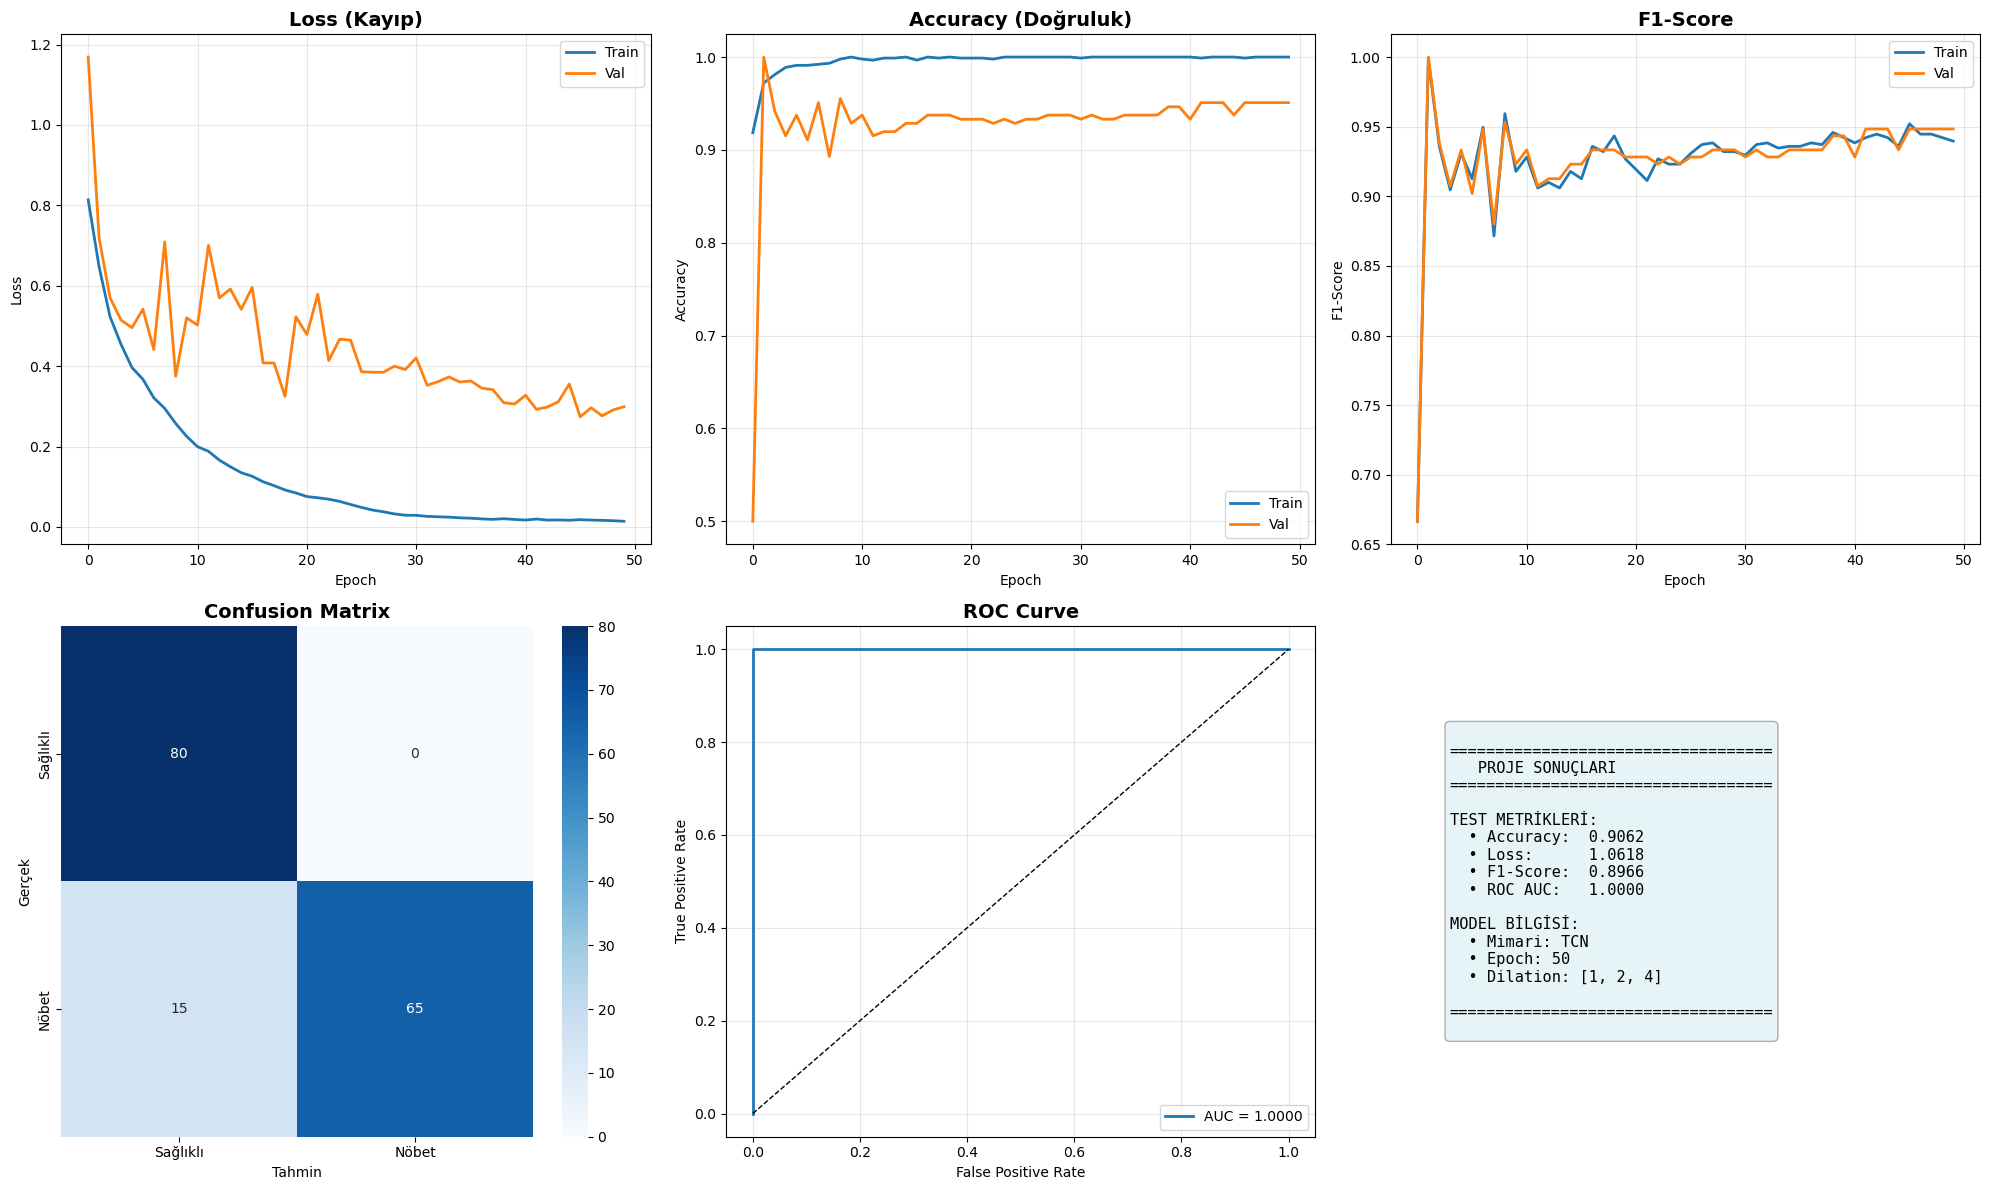


✅ Grafikler kaydedildi: eeg_results.png


In [8]:
# ============================================================================
# HÜCRE 8: TÜM GRAFİKLER
# ============================================================================

fig = plt.figure(figsize=(20, 12))

# 1. Loss
plt.subplot(2, 3, 1)
plt.plot(history.history['loss'], label='Train', linewidth=2)
plt.plot(history.history['val_loss'], label='Val', linewidth=2)
plt.title('Loss (Kayıp)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

# 2. Accuracy
plt.subplot(2, 3, 2)
plt.plot(history.history['accuracy'], label='Train', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Val', linewidth=2)
plt.title('Accuracy (Doğruluk)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

# 3. F1-Score
plt.subplot(2, 3, 3)
plt.plot(f1_callback.f1_train, label='Train', linewidth=2)
plt.plot(f1_callback.f1_val, label='Val', linewidth=2)
plt.title('F1-Score', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('F1-Score')
plt.legend()
plt.grid(alpha=0.3)

# 4. Confusion Matrix
plt.subplot(2, 3, 4)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Sağlıklı', 'Nöbet'],
            yticklabels=['Sağlıklı', 'Nöbet'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Gerçek')
plt.xlabel('Tahmin')

# 5. ROC Curve
plt.subplot(2, 3, 5)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, linewidth=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.title('ROC Curve', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(alpha=0.3)

# 6. Özet
ax = plt.subplot(2, 3, 6)
ax.axis('off')
summary = f"""
{'='*35}
   PROJE SONUÇLARI
{'='*35}

TEST METRİKLERİ:
  • Accuracy:  {test_acc:.4f}
  • Loss:      {test_loss:.4f}
  • F1-Score:  {test_f1:.4f}
  • ROC AUC:   {roc_auc:.4f}

MODEL BİLGİSİ:
  • Mimari: TCN
  • Epoch: {len(history.history['loss'])}
  • Dilation: [1, 2, 4]

{'='*35}
"""
ax.text(0.1, 0.5, summary, fontsize=11, family='monospace',
        verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

plt.tight_layout()
plt.savefig('eeg_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Grafikler kaydedildi: eeg_results.png")

<div style="background-color: #2c3e50; color: white; padding: 10px; text-align: center; border-radius: 5px; font-family: sans-serif;">
    <strong>9. FİNAL RAPOR ÇIKTISI</strong>
</div>

In [9]:
# ============================================================================
# HÜCRE 9: FİNAL RAPOR
# ============================================================================

print("\n" + "="*60)
print("          PROJE TAMAMLANDI")
print("="*60)
print(f"\n TEST ACCURACY: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f" TEST F1-SCORE: {test_f1:.4f}")
print(f" ROC AUC: {roc_auc:.4f}")
print(f"\n Grafik dosyası: eeg_results.png")
print("="*60)


          PROJE TAMAMLANDI

 TEST ACCURACY: 0.9062 (90.62%)
 TEST F1-SCORE: 0.8966
 ROC AUC: 1.0000

 Grafik dosyası: eeg_results.png
